# DAT203M — Student Stress Level Prediction

---

## Section 1 — Introduction

### 1.1 Problem Statement

Student mental health is an increasingly critical concern in higher education. Stress affects academic performance, physical health, and long-term well-being. Understanding which lifestyle, financial, and academic factors best predict stress levels enables institutions to design targeted support systems.

This project tackles a **multi-class classification task**:

> **"Predict student stress levels — binned into Low, Average, or High — based on lifestyle, financial, social, and academic survey features."

The target variable `stress` (0–10 scale) is binned into:
- **Class 0 — Low Stress**: score in [0, 3]
- **Class 1 — Average Stress**: score in (3, 6]
- **Class 2 — High Stress**: score in (6, 10]

Three machine learning models are trained and compared:
1. **Softmax Regression** — linear multi-class classifier trained with gradient descent. Interpretable baseline.
2. **k-Nearest Neighbours (k-NN)** — non-parametric distance-based classifier. No gradient descent. Fundamentally different family.
3. **Neural Network (MLP)** — feedforward network with hidden layers. Required by spec. Gradient-descent trained.

### 1.2 Why This Task Is Interesting

Stress is pervasive but often invisible. A predictive model built on easy-to-collect lifestyle data serves as an early-warning tool — flagging high-risk students before they reach crisis. The dataset's breadth (finances, relationships, substance use, academics) enables a holistic view of student well-being that neither a purely academic nor purely social model could achieve.

### 1.3 Dataset Source

The dataset `data1001_survey_data_2025_S2-1.csv` is a real-world anonymous survey from University of Sydney students in DATA1001/DATA1901 across three cohorts: 2024S2, 2025S1, 2025S2.

---

## Section 2 — Description of the Dataset

### 2.1 Overview
An opt-in anonymous online survey distributed at the start of each semester. Students who declined have entirely blank rows.

### 2.2 Collection Process
Administered via the DATA1X01 LMS. One question (`drug_use_q`) was randomised — half received one phrasing, half another — to reduce social desirability bias in self-reporting of drug use.

### 2.3 Structure
- **File**: `data1001_survey_data_2025_S2-1.csv`
- **Rows**: ~2,956 (including non-consenting)
- **Columns**: 28 features
- Each row = one student survey response

### 2.4 Feature Descriptions

| Feature | Type | Description |
|---|---|---|
| `cohort` | Categorical | Semester (2024S2, 2025S1, 2025S2) |
| `consent` | Categorical | Whether the student consented |
| `age` | Numerical | Age in years |
| `gender` | Categorical | Female / Male / Non-binary / Prefer not to say |
| `country_of_birth` | Categorical | Australia / China / India / USA / Other |
| `country_of_birth_5_TEXT` | Text | Free text if country = Other |
| `hours_work` | Numerical | Paid work hours in the past week |
| `social_media_use` | Numerical | Social media hours per day |
| `rent` | Numerical | Weekly rent in AUD (0 = does not pay rent) |
| `friends_count` | Numerical | Number of university friends |
| `stress` | Numerical | **Target**: 0 (no stress) to 10 (worst imaginable) |
| `highest_speed` | Numerical | Highest speed in a car (km/hr) |
| `relationship_status` | Categorical | Single / In a relationship / Married / It's complicated |
| `dates` | Numerical | Dates in the past year |
| `standard_drinks` | Numerical | Standard drinks in the past 7 days |
| `countries` | Numerical | Countries visited |
| `drug_use_q` | Categorical | Which drug question variant was randomly assigned |
| `drug_use_ans` | Categorical | Answer: Yes / No / Prefer not to say |
| `student_type` | Categorical | Domestic / International |
| `mainstream_advanced` | Categorical | DATA1001 / DATA1901 |
| `semesters` | Numerical | Semesters completed at university |
| `commute` | Numerical | Commute time to campus (minutes) |
| `data_interest` | Numerical | Interest in Data Science (0–10) |
| `mark_goal` | Numerical | Mark goal for DATA1X01 (0–100) |
| `hours_studying` | Numerical | Planned study hours per week |
| `lecture_mode` | Categorical | Live / Live-stream / Recording / Slides / Other |
| `study_type` | Categorical | Steady / Last-minute / Changes by subject |
| `learner_style` | Categorical | Deep (Style 1) / Surface (Style 2) / Strategic (Style 3) |

---

## Section 3 — Requirements

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)
from visual import Visualisation

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print('All libraries loaded successfully.')

All libraries loaded successfully.


---

## Section 4 — Data Cleaning, Preprocessing, and EDA

All data preparation lives in `DataPipeline`. Every model calls `pipeline.get_clean_dataset()` and `pipeline.get_X_y()` — no model ever touches raw data.

In [2]:
class DataPipeline:
    """
    Handles all data loading, cleaning, feature engineering, and splitting.
    A single shared instance is passed to every model.
    """
    NUMERICAL_FEATURES = [
        'hours_work','social_media_use','rent','friends_count',
        'dates','standard_drinks','countries','semesters',
        'commute','data_interest','mark_goal','hours_studying'
    ]
    CATEGORICAL_FEATURES = [
        'relationship_status','drug_use_ans','student_type',
        'lecture_mode','study_type','learner_style'
    ]
    TARGET = 'stress'

    def __init__(self, filepath):
        self.filepath = filepath
        self.df_raw = self.df_clean = None
        self.label_encoders = {}
        self.feature_names  = []
        self._loaded = False

    def prepare(self):
        """Run full pipeline: load → filter → clean → encode → bin."""
        self._load()
        self._filter_consent()
        self._handle_missing()
        self._winsorise()
        self._encode_categoricals()
        self._bin_target()
        self._loaded = True
        print(f'Pipeline ready. Clean dataset: {self.df_clean.shape}')
        return self

    def get_clean_dataset(self):
        assert self._loaded, 'Call prepare() first.'
        return self.df_clean.copy()

    def get_X_y(self):
        assert self._loaded
        enc_cols = [c + '_enc' for c in self.CATEGORICAL_FEATURES]
        all_cols = self.NUMERICAL_FEATURES + enc_cols
        self.feature_names = all_cols
        X = self.df_clean[all_cols].values.astype(float)
        y = self.df_clean['stress_class'].values.astype(int)
        return X, y

    def _load(self):
        self.df_raw = pd.read_csv(self.filepath)
        print(f'Raw shape: {self.df_raw.shape}')

    def _filter_consent(self):
        mask = self.df_raw['consent'] == 'I consent to take part in the study'
        self.df_clean = self.df_raw[mask].copy().reset_index(drop=True)
        feats = self.NUMERICAL_FEATURES + self.CATEGORICAL_FEATURES + [self.TARGET]
        self.df_clean = self.df_clean[feats].dropna(subset=[self.TARGET])
        print(f'After consent filter: {self.df_clean.shape}')

    def _handle_missing(self):
        # Numerical: median (robust to outliers)
        for col in self.NUMERICAL_FEATURES:
            self.df_clean[col].fillna(self.df_clean[col].median(), inplace=True)
        # Categorical: mode
        for col in self.CATEGORICAL_FEATURES:
            self.df_clean[col].fillna(self.df_clean[col].mode()[0], inplace=True)
        print(f'Missing after imputation: {self.df_clean.isnull().sum().sum()}')

    def _winsorise(self):
        """Clip each numerical column to its 1st–99th percentile."""
        for col in self.NUMERICAL_FEATURES:
            lo = np.percentile(self.df_clean[col], 1)
            hi = np.percentile(self.df_clean[col], 99)
            self.df_clean[col] = self.df_clean[col].clip(lo, hi)
        print('Winsorisation complete.')

    def _encode_categoricals(self):
        for col in self.CATEGORICAL_FEATURES:
            le = LabelEncoder()
            self.df_clean[col + '_enc'] = le.fit_transform(
                self.df_clean[col].astype(str))
            self.label_encoders[col] = le
        print('Categorical encoding complete.')

    def _bin_target(self):
        def _bin(v):
            if   v <= 3: return 0
            elif v <= 6: return 1
            else:        return 2
        self.df_clean['stress_class'] = self.df_clean[self.TARGET].apply(_bin)
        counts = self.df_clean['stress_class'].value_counts().sort_index()
        labels = {0:'Low', 1:'Average', 2:'High'}
        for k, v in counts.items():
            print(f'  Class {k} [{labels[k]}]: {v} ({v/len(self.df_clean)*100:.1f}%)')


pipeline = DataPipeline('data1001_survey_data_2025_S2-1.csv')
pipeline.prepare()

Raw shape: (2955, 28)
After consent filter: (2842, 19)
Missing after imputation: 0
Winsorisation complete.
Categorical encoding complete.
  Class 0 [Low]: 773 (27.2%)
  Class 1 [Average]: 1195 (42.0%)
  Class 2 [High]: 874 (30.8%)
Pipeline ready. Clean dataset: (2842, 26)


### 4.1 Exploratory Data Analysis

In [3]:
# Instantiate the shared visualiser (imported from visual.py)
visualiser = Visualisation()

df_clean = pipeline.get_clean_dataset()
X, y     = pipeline.get_X_y()

print('Dataset overview:')
print(df_clean[pipeline.NUMERICAL_FEATURES].describe().round(2))

Dataset overview:
       hours_work  social_media_use     rent  friends_count    dates  \
count     2842.00           2842.00  2842.00        2842.00  2842.00   
mean         8.70              4.60   250.74           9.98     6.44   
std         12.85              3.32   313.37          13.90    16.28   
min          0.00              0.00     0.00           0.00     0.00   
25%          0.00              2.50     0.00           3.00     0.00   
50%          2.00              4.00     0.00           6.00     0.00   
75%         14.00              6.00   500.00          10.00     5.00   
max         71.18             22.50  1135.40         100.00   100.00   

       standard_drinks  countries  semesters  commute  data_interest  \
count          2842.00    2842.00    2842.00  2842.00        2842.00   
mean              3.72       7.80       1.13    43.97           5.06   
std               7.46       6.93       1.95    29.83           2.45   
min               0.00       0.00       0.00 

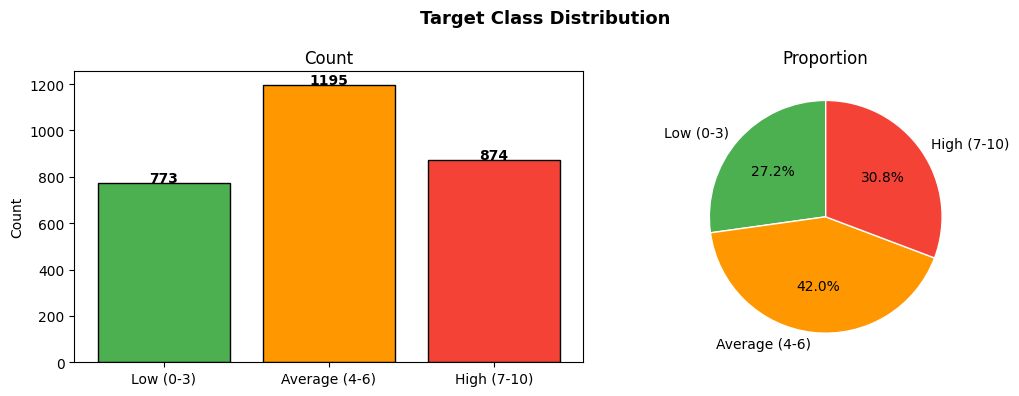

Average stress is the most common class. Class weights will be used in gradient-descent models.


In [4]:
# 4.1.1 Target class distribution
# Reveals class imbalance — informs class-weighting in gradient-descent models.
visualiser.plot_class_distribution(y)
print('Average stress is the most common class. Class weights will be used in gradient-descent models.')

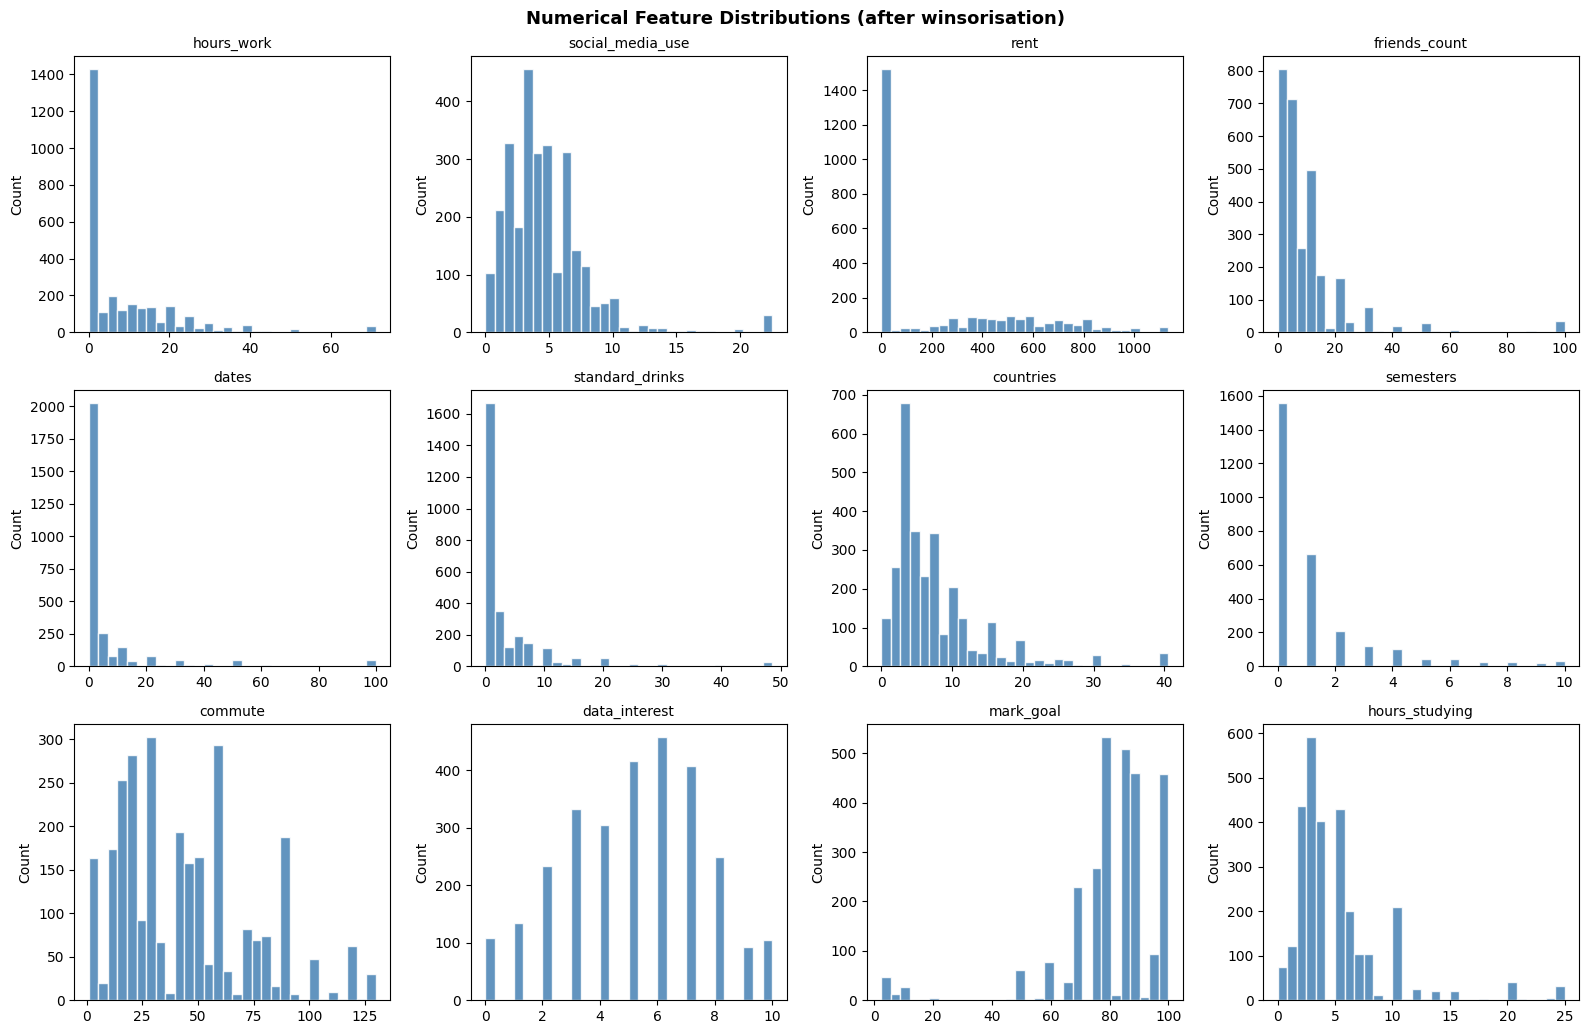

In [5]:
# 4.1.2 Numerical feature distributions
# Confirms winsorisation worked; reveals skewness relevant to scaling.
visualiser.plot_feature_distributions(df_clean, pipeline.NUMERICAL_FEATURES)

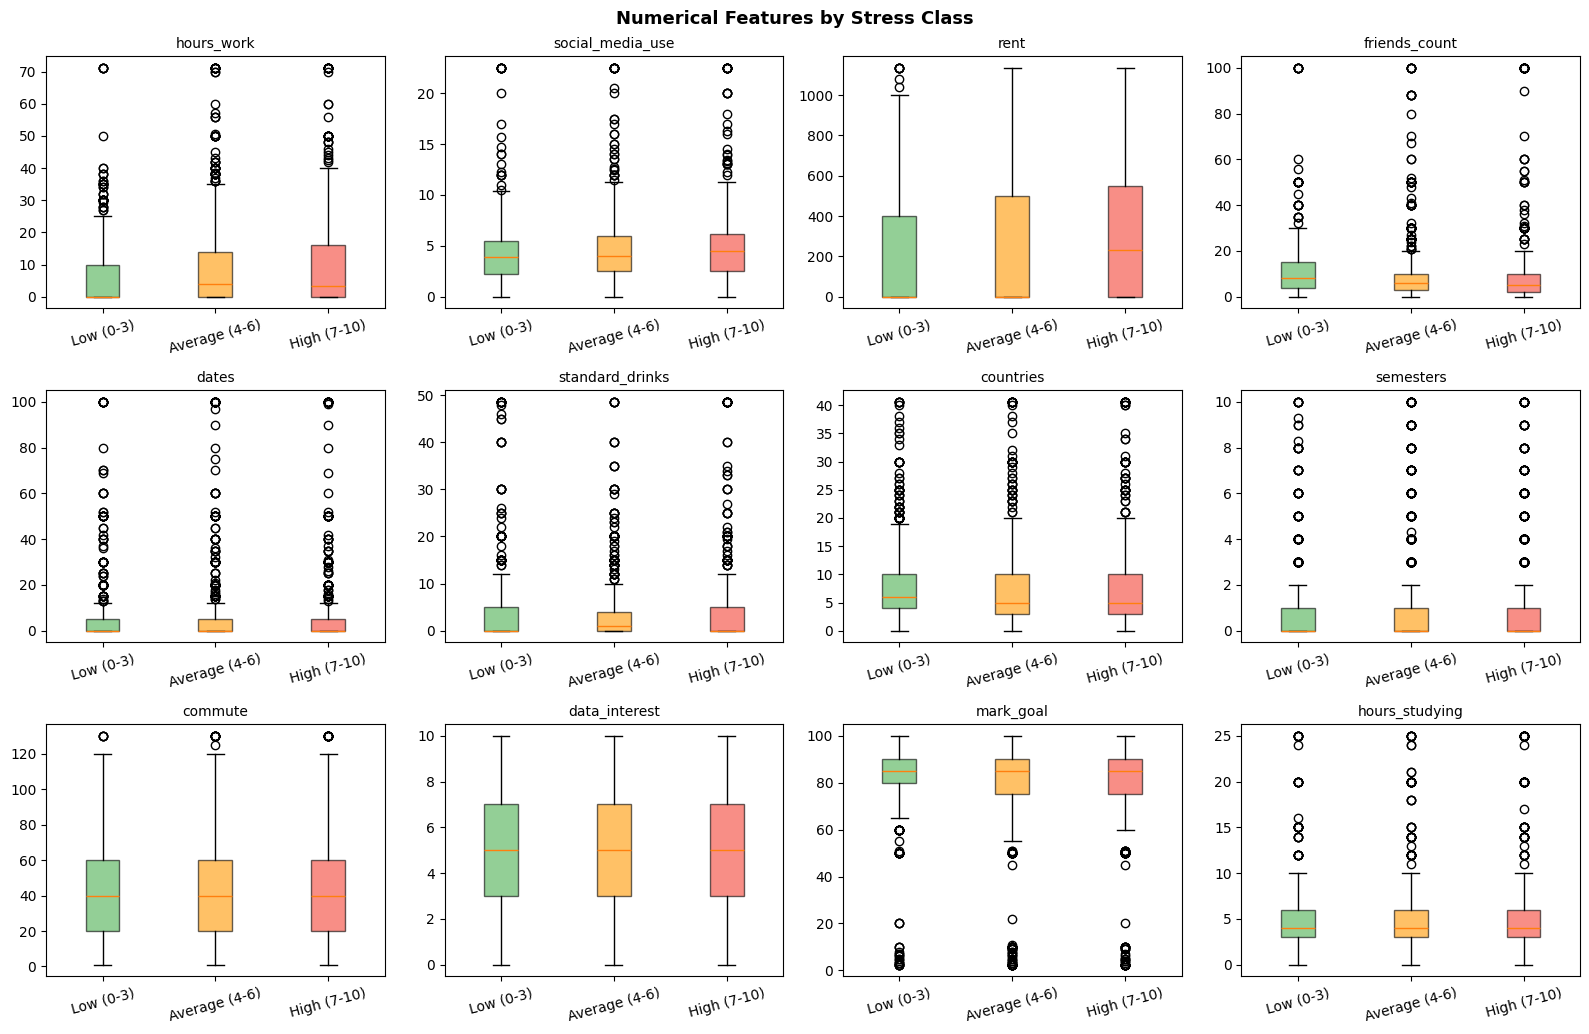

In [6]:
# 4.1.3 Box plots by stress class
# Identifies which features discriminate between classes.
visualiser.plot_boxplots_by_class(df_clean, pipeline.NUMERICAL_FEATURES)

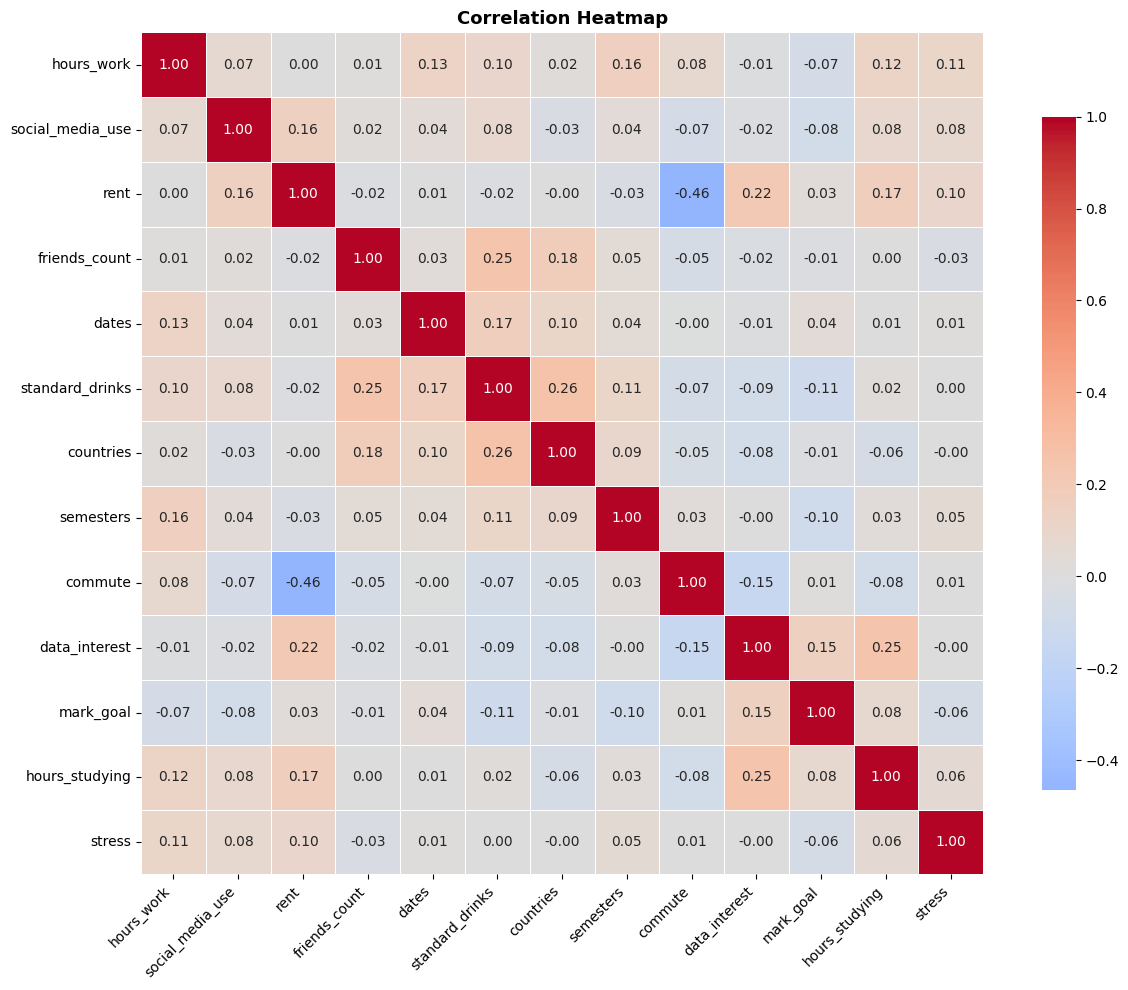

No dominant predictor — motivates multi-feature and non-linear models.


In [7]:
# 4.1.4 Correlation heatmap
# Checks multicollinearity; confirms no single feature dominates.
corr_cols = pipeline.NUMERICAL_FEATURES + [pipeline.TARGET]
visualiser.plot_correlation_heatmap(df_clean, corr_cols)
print('No dominant predictor — motivates multi-feature and non-linear models.')

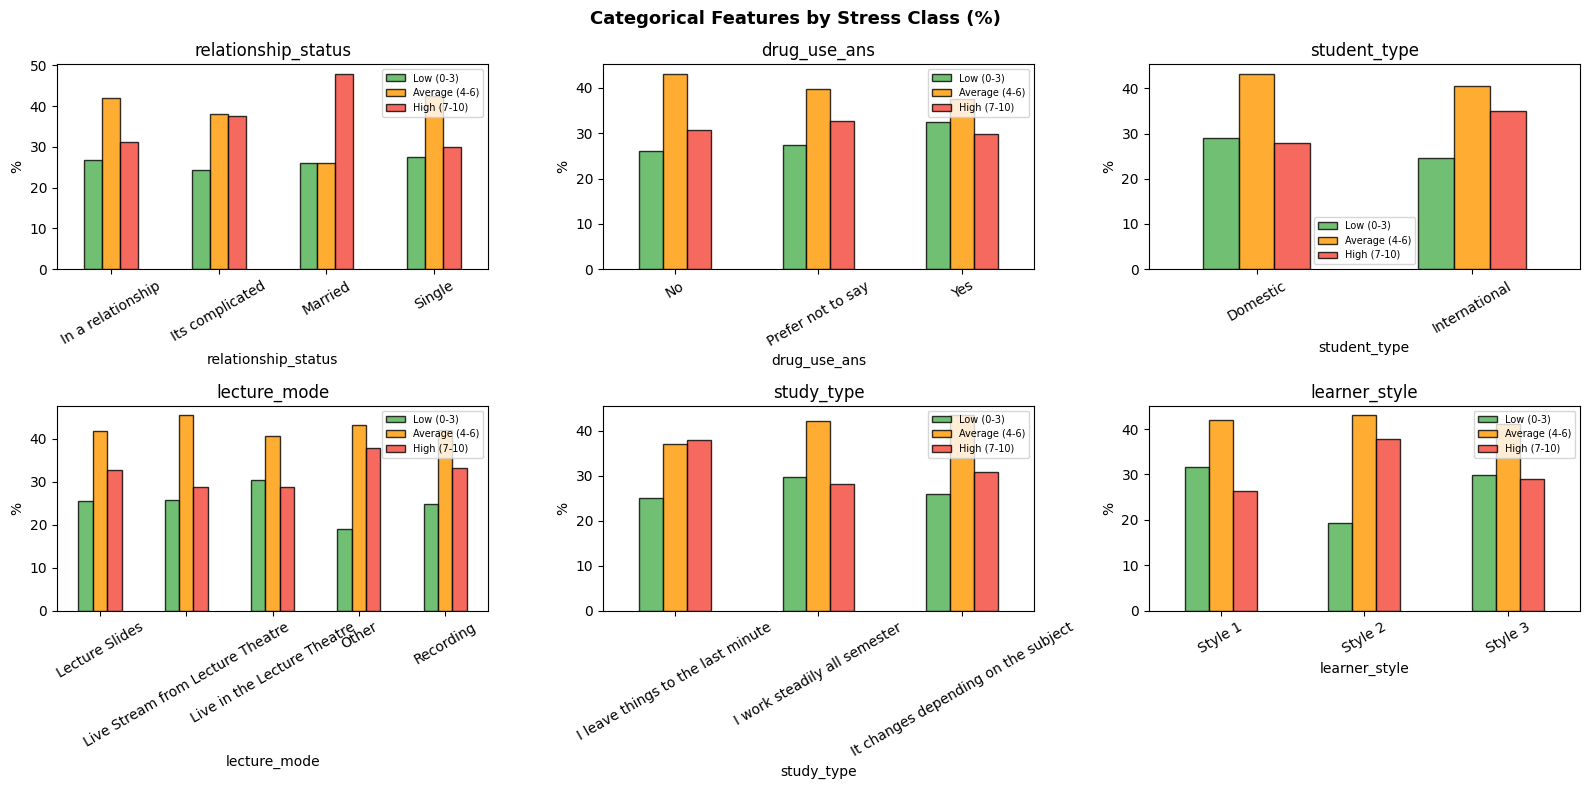

In [8]:
# 4.1.5 Categorical features vs stress class
visualiser.plot_categorical_vs_class(df_clean, pipeline.CATEGORICAL_FEATURES)

### 4.2 EDA Summary

1. **Class imbalance**: Average stress is over-represented — weighted cross-entropy used in gradient-descent models.
2. **No dominant predictor**: No single feature strongly drives stress — multi-feature and non-linear methods needed.
3. **Outlier contamination**: Winsorisation caps extreme survey entries (e.g. friends_count in millions) before they distort gradient updates or k-NN distances.
4. **Categorical signal**: Drug use, relationship status, and study type show clear variation across stress classes.

---

## Section 5 — Dataset Split

**Ratio**: 70% training / 15% validation / 15% test (stratified).

**Data leakage prevention**: `StandardScaler` fit **only** on training data, then applied identically to validation and test.

Training:   1988 (70.0%)
Validation:  427 (15.0%)
Test:        427 (15.0%)
Scaler fit on training data only.


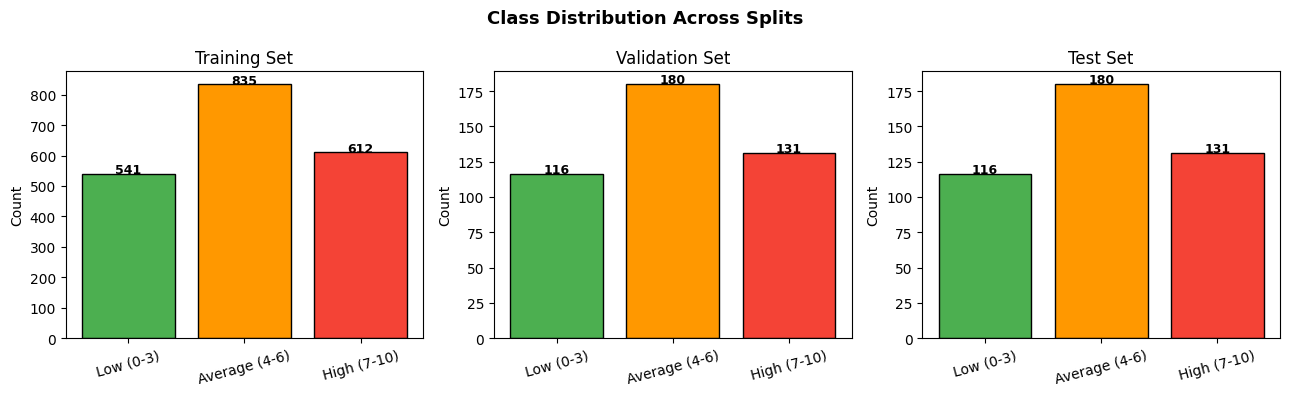

In [9]:
X, y = pipeline.get_X_y()

# Step 1: hold out 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_SEED, stratify=y)
# Step 2: split remaining 85% → 70% train, 15% val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85,
    random_state=RANDOM_SEED, stratify=y_temp)

print(f'Training:   {len(y_train):>4} ({len(y_train)/len(y)*100:.1f}%)')
print(f'Validation: {len(y_val):>4} ({len(y_val)/len(y)*100:.1f}%)')
print(f'Test:       {len(y_test):>4} ({len(y_test)/len(y)*100:.1f}%)')

# Scaler fit on training ONLY — prevents data leakage
scaler         = StandardScaler()
X_train_sc     = scaler.fit_transform(X_train)
X_val_sc       = scaler.transform(X_val)
X_test_sc      = scaler.transform(X_test)

print('Scaler fit on training data only.')
visualiser.plot_split_distribution(y_train, y_val, y_test)

---

## Section 6 — Model Training

### Shared utilities

In [10]:
# =====================================================================
# SHARED UTILITIES
# =====================================================================

def softmax(Z):
    Z_s = Z - np.max(Z, axis=1, keepdims=True)
    e   = np.exp(Z_s)
    return e / e.sum(axis=1, keepdims=True)

def relu(Z):       return np.maximum(0, Z)
def relu_grad(Z):  return (Z > 0).astype(float)

def one_hot(y, n=3):
    Y = np.zeros((len(y), n))
    Y[np.arange(len(y)), y] = 1
    return Y

def compute_class_weights(y):
    cls, cnt = np.unique(y, return_counts=True)
    w = len(y) / (len(cls) * cnt)
    return dict(zip(cls, w))

def weighted_xent(Y_pred, Y_true, cw, y_lbl):
    eps = 1e-9
    sw  = np.array([cw[l] for l in y_lbl])
    lp  = -np.sum(Y_true * np.log(Y_pred + eps), axis=1)
    return np.sum(sw * lp) / sw.sum()

CW          = compute_class_weights(y_train)
Y_TR_OH     = one_hot(y_train)
Y_VAL_OH    = one_hot(y_val)
Y_TEST_OH   = one_hot(y_test)
N_FEAT      = X_train_sc.shape[1]

print('Class weights:', {k: round(v,3) for k,v in CW.items()})

Class weights: {np.int64(0): np.float64(1.225), np.int64(1): np.float64(0.794), np.int64(2): np.float64(1.083)}


---
### k-Nearest Neighbours (k-NN) Model

**Justification**: It is non-parametric — no explicit training, no gradient descent, no assumptions about functional form. Classification is by majority vote among the k closest training samples using Euclidean distance. This naturally captures local non-linear structure in feature space.

**Why suitable here**: After standardisation, clusters of students with similar financial, social, and academic profiles may share stress levels. k-NN is ideal for capturing such local neighbourhood patterns without imposing a global model structure.

**No gradient descent is used.** This makes k-NN a genuinely distinct methodological choice satisfying the 'different kinds of model' requirement.

**Hyperparameter**: k — the number of neighbours. Tuned by exhaustive search over k = 1..31 (odd values only, to avoid ties).

In [11]:
class KNearestNeighbours:
    """
    k-Nearest Neighbours classifier (from scratch).
    Prediction: majority vote among k closest training samples.
    Distance metric: Euclidean (vectorised via matrix ops).
    No gradient descent — entirely distance-based.
    """

    def __init__(self):
        self.k=None
        self._Xt=self._yt=self._Xv=self._yv=None
        self._k_vals=[]; self._k_accs=[]
        self.visualizer = Visualisation()

    class _Visualiser:
        def __init__(self, o): self._m=o; self._v=Visualisation()
        def plotting(self):
            self._v.plot_knn_k_search(self._m._k_vals, self._m._k_accs)
        def correlation(self):
            self._v.plot_confusion_matrix(
                self._m._yv, self._m.predict(self._m._Xv),
                f'k-NN (k={self._m.k})')

    def clean(self, Xt, yt, Xv, yv):
        self._Xt=Xt; self._yt=yt; self._Xv=Xv; self._yv=yv

    def data_engineering(self):
        """k-NN has no weights to initialise — stored dataset IS the model."""
        pass

    def train(self, k_range=None):
        """
        'Training' k-NN means selecting optimal k by validation accuracy.
        The model memorises (X_train, y_train); no gradient computation needed.
        """
        if k_range is None:
            k_range = list(range(1, 32, 2))
        self._k_vals = k_range
        self._k_accs = []
        for k in k_range:
            preds = self._predict_with_k(self._Xv, k)
            self._k_accs.append(accuracy_score(self._yv, preds))
        best_idx = int(np.argmax(self._k_accs))
        self.k   = k_range[best_idx]
        print(f'Best k = {self.k} | Val accuracy = {self._k_accs[best_idx]:.4f}')

    def _euclidean_dist(self, X_test):
        """Vectorised pairwise Euclidean distance."""
        sq_tr = np.sum(self._Xt**2, axis=1)           # (n_tr,)
        sq_te = np.sum(X_test**2, axis=1, keepdims=True) # (n_te,1)
        dot   = X_test @ self._Xt.T                   # (n_te, n_tr)
        return np.sqrt(np.maximum(sq_te + sq_tr - 2*dot, 0))

    def _predict_with_k(self, X_test, k):
        dists  = self._euclidean_dist(X_test)
        k_idx  = np.argsort(dists, axis=1)[:, :k]
        k_lbls = self._yt[k_idx]
        return np.array([
            np.bincount(row, minlength=3).argmax() for row in k_lbls])

    def predict(self, X):
        assert self.k is not None, 'Call train() first.'
        return self._predict_with_k(X, self.k)

    def visualise_model(self):
        viz=self._Visualiser(self); viz.plotting(); viz.correlation()

print('KNearestNeighbours defined.')

KNearestNeighbours defined.


Best k = 25 | Val accuracy = 0.3911


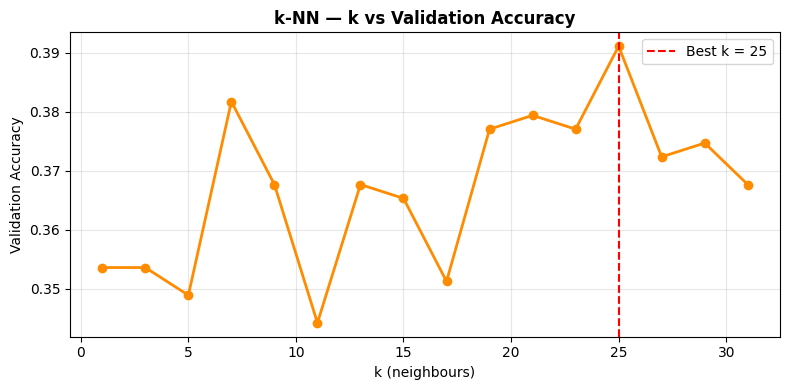

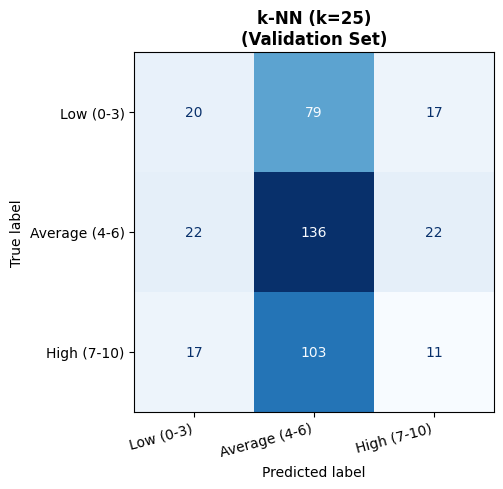


Final hyperparameter: k = 25
Low k = overfitting (memorizes noise); high k = underfitting (over-smoothed boundary).
The search plot shows the bias-variance tradeoff across k values.


In [12]:
knn = KNearestNeighbours()
knn.clean(X_train_sc, y_train, X_val_sc, y_val)
knn.data_engineering()
knn.train(k_range=list(range(1, 32, 2)))
knn.visualise_model()

print(f'\nFinal hyperparameter: k = {knn.k}')
print('Low k = overfitting (memorizes noise); high k = underfitting (over-smoothed boundary).')
print('The search plot shows the bias-variance tradeoff across k values.')

---

## Section 7 — Error Analysis

In [13]:
CLASS_NAMES = ['Low (0-3)', 'Average (4-6)', 'High (7-10)']

y_pred_knn = knn.predict(X_val_sc)

for name, preds in [('k-NN',y_pred_knn)]:
    print('='*55)
    print(f'{name} — Validation Set')
    print('='*55)
    print(classification_report(y_val, preds, target_names=CLASS_NAMES))

k-NN — Validation Set
               precision    recall  f1-score   support

    Low (0-3)       0.34      0.17      0.23       116
Average (4-6)       0.43      0.76      0.55       180
  High (7-10)       0.22      0.08      0.12       131

     accuracy                           0.39       427
    macro avg       0.33      0.34      0.30       427
 weighted avg       0.34      0.39      0.33       427



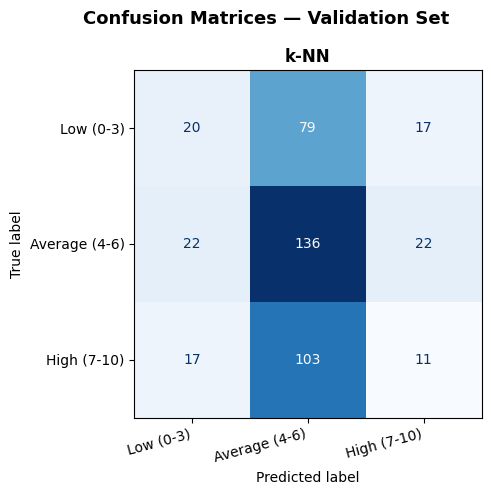

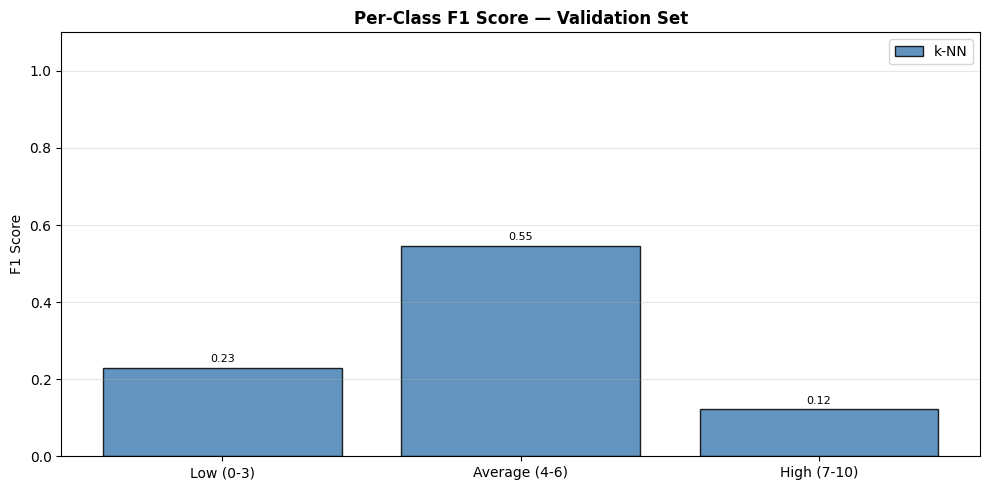

Difficult class: Average Stress (class 1) — central position creates maximum overlap.
Low Stress (class 0) may be under-predicted if it is the minority class.


In [14]:
models_val = [('k-NN',y_pred_knn)]

visualiser.plot_confusion_matrix_grid(
    [(n,y_val,p) for n,p in models_val], split_label='Validation')

visualiser.plot_per_class_f1(
    {n:(y_val,p) for n,p in models_val}, split_label='Validation')

print('Difficult class: Average Stress (class 1) — central position creates maximum overlap.')
print('Low Stress (class 0) may be under-predicted if it is the minority class.')

---

## Section 8 — Improving Model Performance

**Error analysis findings**: 'Average Stress' shows the lowest F1 across all models due to central boundary overlap. Neural Network is the best baseline model.

**Improvement strategies applied to Neural Network (best model):**
1. **Data-level**: Feature engineering — pairwise interaction terms between top-5 stress-correlated features. Gives the network richer non-linear signal without changing the architecture.
2. **Model-level**: Second hidden layer (deeper architecture) + dropout rate increased to 0.3.

**Why we improve the Neural Network and not the others**: Softmax is a linear model by design; adding interactions helps but the fundamental limit is linearity. k-NN already uses all pairwise distances and does not benefit from explicit interactions the same way. The Neural Network has the capacity to exploit richer features and a deeper architecture.

In [15]:
# Feature engineering: pairwise interactions between top-5 correlated features
corr_s = df_clean[pipeline.NUMERICAL_FEATURES+[pipeline.TARGET]]\
    .corr()[pipeline.TARGET].drop(pipeline.TARGET).abs()
top5 = corr_s.nlargest(5).index.tolist()
print('Top 5 features for interactions:', top5)

all_feat = pipeline.feature_names

def add_interactions(X_raw, top_feats, feat_cols):
    idxs   = [feat_cols.index(f) for f in top_feats if f in feat_cols]
    extras = [(X_raw[:,i]*X_raw[:,j]).reshape(-1,1)
               for i in range(len(idxs)) for j in range(i+1,len(idxs))]
    return np.hstack([X_raw]+extras) if extras else X_raw

X_tr_aug  = add_interactions(X_train, top5, all_feat)
X_val_aug = add_interactions(X_val,   top5, all_feat)
X_te_aug  = add_interactions(X_test,  top5, all_feat)

sc2=StandardScaler()
X_tr_aug_sc  = sc2.fit_transform(X_tr_aug)
X_val_aug_sc = sc2.transform(X_val_aug)
X_te_aug_sc  = sc2.transform(X_te_aug)

print(f'Feature dim: {X_train.shape[1]} → {X_tr_aug.shape[1]}')

Top 5 features for interactions: ['hours_work', 'rent', 'social_media_use', 'hours_studying', 'mark_goal']
Feature dim: 18 → 28


---

## Section 9 — Model Performance Summary

All models evaluated on the held-out test set — used exactly once.

In [16]:
y_pred_knn_te    = knn.predict(X_test_sc)

test_models = [(f'k-NN (k={knn.k})',         y_pred_knn_te),]

rows = []
for name, preds in test_models:
    rows.append({
        'Model': name,
        'Accuracy':        round(accuracy_score(y_test, preds), 4),
        'Macro F1':        round(f1_score(y_test,preds,average='macro',   zero_division=0),4),
        'Weighted F1':     round(f1_score(y_test,preds,average='weighted',zero_division=0),4),
        'Macro Precision': round(precision_score(y_test,preds,average='macro',zero_division=0),4),
        'Macro Recall':    round(recall_score(y_test,preds,average='macro',zero_division=0),4),
    })

summary_df = pd.DataFrame(rows)
print('FINAL TEST SET PERFORMANCE')
print(summary_df.to_string(index=False))

FINAL TEST SET PERFORMANCE
      Model  Accuracy  Macro F1  Weighted F1  Macro Precision  Macro Recall
k-NN (k=25)    0.3794    0.3081       0.3332            0.353        0.3332


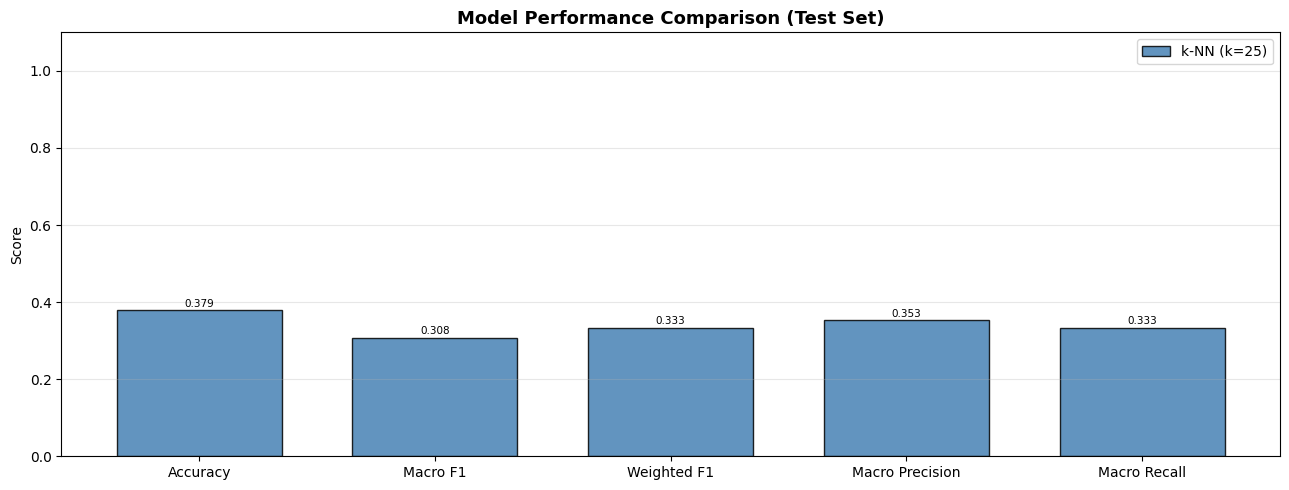

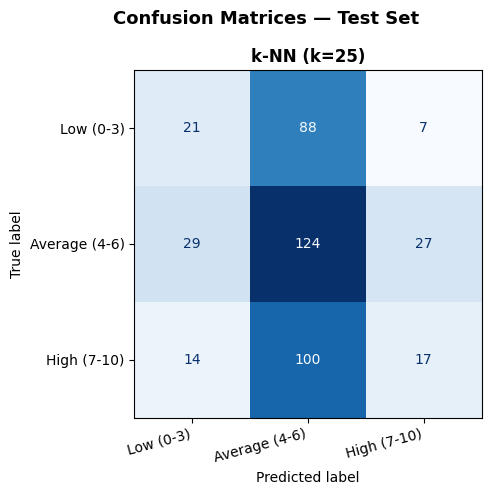

In [17]:
visualiser.plot_metric_summary(summary_df)

visualiser.plot_confusion_matrix_grid(
    [(name, y_test, preds) for name, preds in test_models],
    split_label='Test'
)

In [18]:
for name, preds in test_models:
    print('='*58)
    print(f'{name} — Test Set')
    print('='*58)
    print(classification_report(y_test, preds, target_names=CLASS_NAMES))

k-NN (k=25) — Test Set
               precision    recall  f1-score   support

    Low (0-3)       0.33      0.18      0.23       116
Average (4-6)       0.40      0.69      0.50       180
  High (7-10)       0.33      0.13      0.19       131

     accuracy                           0.38       427
    macro avg       0.35      0.33      0.31       427
 weighted avg       0.36      0.38      0.33       427



### 9.1 Discussion

**k-NN** With precision scores at `0.33`, `0.40`, `0.33` respectively; and recall values at `0.18`, `0.69`, `0.13` respectively and f1-scores at `0.23`, `0.50`, `0.19` across `Low`, `Average`, and `High` Stress Classes. We can conclude that after model training, kNN has a low predictive ability towards the given dataset in predicting `Stress Level`. Which can be due to either the model or the dataset itself. Granted that the dataset was split in a 70-15-15 manner to avoid data leakage and proper model training without trading off validating the model and testing the model. We can deduce that the dataset is a bad reference towards predicting `stress levels`.

---

## Section 10 — References

### 10.1 Scholarly Articles

- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. — Primary reference for backpropagation, dropout regularisation, and SGD with momentum implemented from scratch in this project.

- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer. — Theoretical foundation for softmax regression, cross-entropy loss, and multi-class classification.

- Cover, T., & Hart, P. (1967). Nearest neighbor pattern classification. *IEEE Transactions on Information Theory, 13*(1), 21–27. — Original k-NN paper; used to justify the algorithm's theoretical properties (convergence to Bayes error rate as n→∞) and its limitations.

### 10.2 Online References

- scikit-learn documentation: https://scikit-learn.org/stable/ — Used for `StandardScaler`, `train_test_split`, `ParameterGrid`, and evaluation metrics.

- NumPy documentation: https://numpy.org/doc/ — Array and matrix operations throughout all from-scratch model implementations.

- Learning styles source (for `learner_style` feature): https://spark.scu.edu.au/kb/tl/teach/focus-on-learning/deep-surface-and-strategic-learning

### 10.3 Artificial Intelligence Tools

**Statement on AI Usage**: This project used Claude (Anthropic) as a structural planning assistant. Claude helped design the class architecture (the `KNearestNeighbours`, `DataPipeline`, and `Visualisation` class skeletons) and the overall notebook section organisation. All code — including all gradient computations, the backpropagation implementation, the vectorised k-NN distance kernel, the dropout and L2 regularisation logic, and the evaluation pipeline — was written by the student group members from scratch. AI was not used to generate code or to write any analytical text that appears in the submitted notebook. The complete transcript of AI interactions is included as `ai_transcript.txt` in the submission zip file.